# 03 — Customer Analysis

This notebook aggregates transactions to the customer level to study purchase frequency, repeat vs. one-time buyer behavior, and the highest-value customers. **Input:** `customer_df.csv` from `01_data_cleaning`. It answers: how are orders distributed across customers, do repeat buyers spend differently than one-time buyers, who are the top customers by revenue and order volume, and how does purchase behavior vary by country and over time?

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

### Load Data
`customer_df` from `data/processed/`.

In [2]:
customer_df = pd.read_csv('../data/processed/customer_df.csv')

# Purchase Frequency Distribution
Distribution of orders-per-customer across the whole customer base.

### Orders per Customer
Load orders per customer, computed in 02.

In [3]:
orders_per_customer = pd.read_csv('../data/processed/orders_per_customer.csv')
orders_per_customer

,Customer ID,Number_of_Orders
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1
...,...,...
4333,18280,1
4334,18281,1
4335,18282,2
4336,18283,16


### Distribution Plot
Tail capped at 10+.

Text(0, 0.5, 'Number of Customers ')

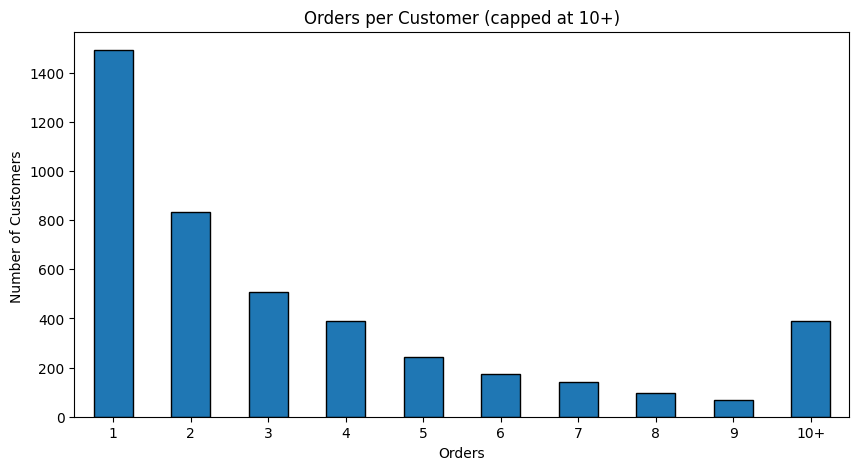

In [4]:
order_dist = orders_per_customer['Number_of_Orders'].clip(upper=10).value_counts().sort_index()
order_dist.index = order_dist.index.astype(str)
order_dist.index = order_dist.index.where(order_dist.index != '10', '10+')

ax = order_dist.plot(
    kind='bar', figsize=(10, 5), edgecolor='black',
    title='Orders per Customer (capped at 10+)', rot=0,
)
ax.set_xlabel('Orders')
ax.set_ylabel('Number of Customers ')

# Repeat vs. One-Time Buyer Behavior
Deeper comparison than the single repeat-rate number from 02.

### Split Customers into Groups
Repeat vs. one-time, based on `Number_of_Orders` — computed independently here, not loaded from 02.

<Axes: title={'center': 'Repeat vs One-time Customers'}, xlabel='is_repeat_customer'>

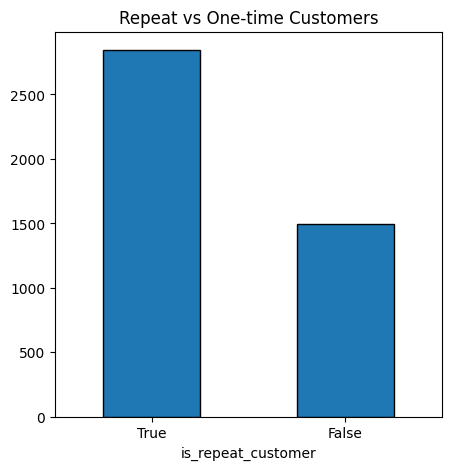

In [5]:
orders_per_customer['is_repeat_customer'] = orders_per_customer['Number_of_Orders'] > 1

orders_per_customer['is_repeat_customer'].value_counts().plot(
    kind='bar',
    figsize=(5, 5),
    edgecolor='black',
    title='Repeat vs One-time Customers',
    rot=0
)

### Compare Spend per Group
Average revenue per customer, repeat vs. one-time.

In [6]:
revenue_per_customer = customer_df[~customer_df['is_cancelled']].groupby('Customer ID')['line_revenue'].sum().reset_index()
revenue_per_customer.head()

,Customer ID,line_revenue
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [7]:
revenue_per_customer.to_csv('../data/processed/revenue_per_customer.csv', index=False)

<Axes: title={'center': 'Average Revenue per Customer: Repeat vs One-time'}, xlabel='is_repeat_customer'>

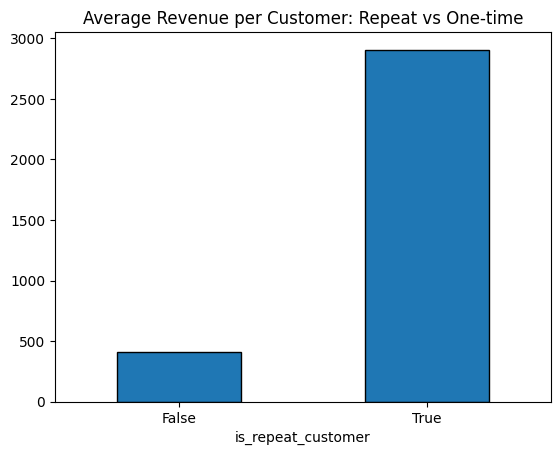

In [8]:
revenue_per_customer = revenue_per_customer.merge(
    orders_per_customer[['Customer ID', 'is_repeat_customer']], on='Customer ID'
)
average_revenue_per_customer = revenue_per_customer.groupby('is_repeat_customer')['line_revenue'].mean()
average_revenue_per_customer.plot(kind='bar', edgecolor='black', title='Average Revenue per Customer: Repeat vs One-time', rot=0)

# Top Customers

### By Revenue
Top N customers ranked by total non-cancelled revenue.

In [9]:
top_customers = customer_df[(customer_df['is_cancelled'] == False) & (customer_df['is_zero_value'] == False)].groupby('Customer ID').agg(
    total = ("line_revenue" , "sum")).sort_values(by = ["total"], ascending= False)
top_customers.head(10)

,total
Customer ID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


### By Order Volume
Top N customers ranked by number of orders.

In [10]:
number_orders = (
    customer_df[(customer_df['is_cancelled'] == False) & (customer_df['is_zero_value'] == False)]
    .groupby('Customer ID')['Invoice']
    .nunique()
    .sort_values(ascending=False)
)
number_orders.head(10)

Customer ID
12748    209
14911    201
17841    124
13089     97
14606     93
15311     91
12971     86
14646     73
16029     63
13408     62
Name: Invoice, dtype: int64

**Overlap between the two top-10 lists.** Only 3 of the top 10 customers by revenue also appear in the top 10 by order volume — Customers **14646, 14911, and 16029**. The other 7 in each list are distinct customers.

This suggests high-value customers split into two different types: big-basket/infrequent buyers (high revenue per order, few orders) and frequent/moderate-basket buyers (many orders, lower revenue each). They likely need different retention approaches — white-glove/VIP treatment for the former, frequency or loyalty incentives for the latter — rather than one blanket "top customer" program.

# Visualize Purchase Patterns
Any other useful cuts — e.g. spend/frequency by country, or over time.

## Spend by country
Which countries generate the most revenue?

Text(0, 0.5, 'Gross Sales (log scale)')

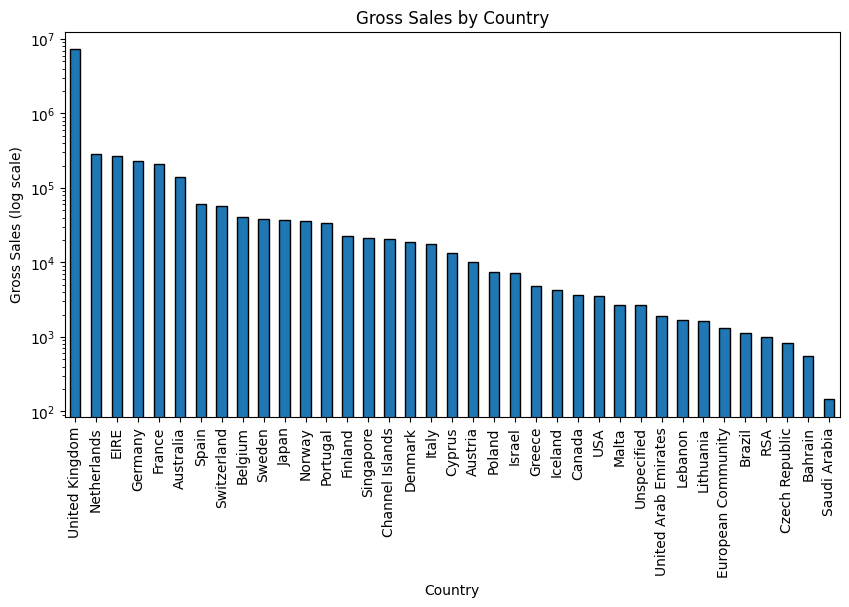

In [11]:
spend_by_country = customer_df[~customer_df['is_cancelled']].groupby('Country')['line_revenue'].sum().sort_values(ascending=False)
ax = spend_by_country.plot(kind='bar', edgecolor='black', logy=True, figsize=(10, 5), title='Gross Sales by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Gross Sales (log scale)')

## Number of orders by country
Which countries have the most orders?

Text(0, 0.5, 'Number of Orders (log scale)')

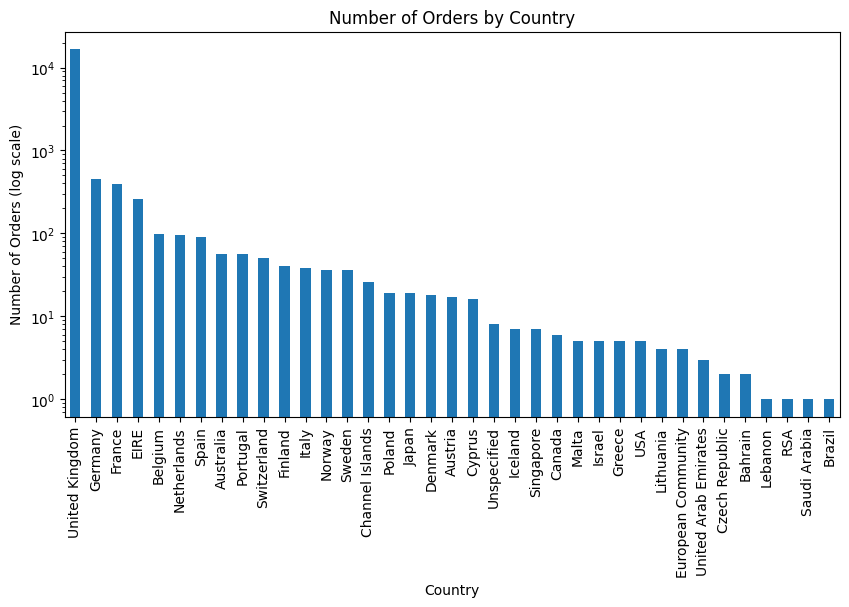

In [12]:
norder_by_country = customer_df[~customer_df['is_cancelled']].groupby('Country')['Invoice'].nunique().sort_values(ascending=False)
ax = norder_by_country.plot(kind='bar', logy=True, figsize=(10, 5), title='Number of Orders by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Orders (log scale)')

## Average order value by country
Are customers in some countries spending more per order?

Text(0, 0.5, 'Average Order Value')

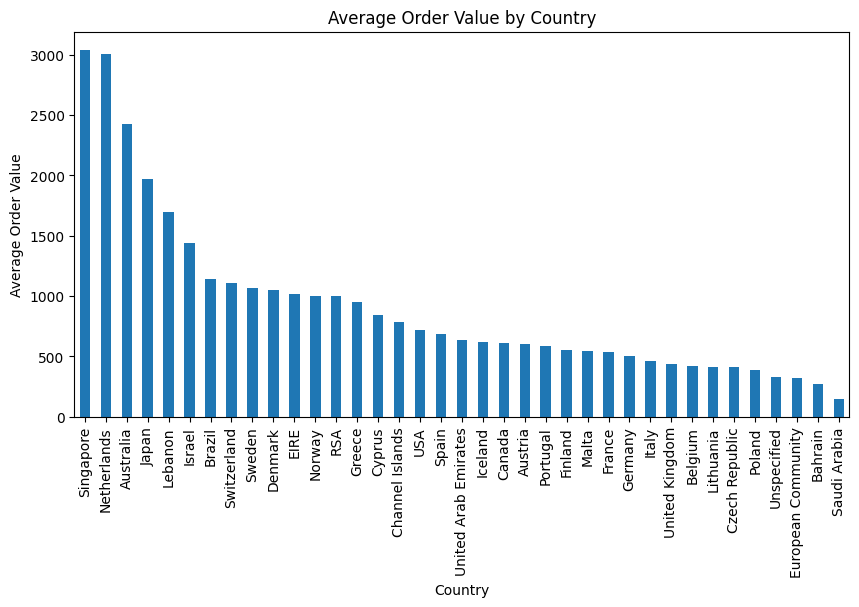

In [13]:
invoice_totals_by_country = customer_df[~customer_df['is_cancelled']].groupby(['Country', 'Invoice'])['line_revenue'].sum()
avg_order_by_country = invoice_totals_by_country.groupby('Country').mean().sort_values(ascending=False)
ax = avg_order_by_country.plot(kind='bar', figsize=(10, 5), title='Average Order Value by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Average Order Value')

## Revenue over time

<Axes: title={'center': 'Revenue Over Time'}, xlabel='month'>

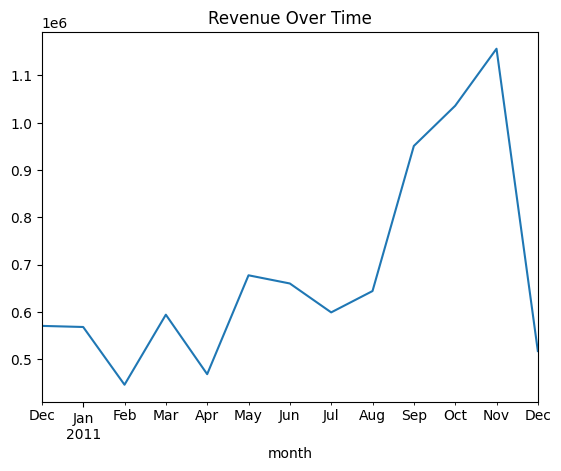

In [14]:
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])
customer_df['month'] = customer_df['InvoiceDate'].dt.to_period('M')
revenue_overtime = customer_df[~customer_df['is_cancelled']].groupby('month')['line_revenue'].sum()
revenue_overtime.plot(kind='line', title='Revenue Over Time')

## Orders over time
Are people buying more frequently over time?

<Axes: title={'center': 'Orders Over Time'}, xlabel='month'>

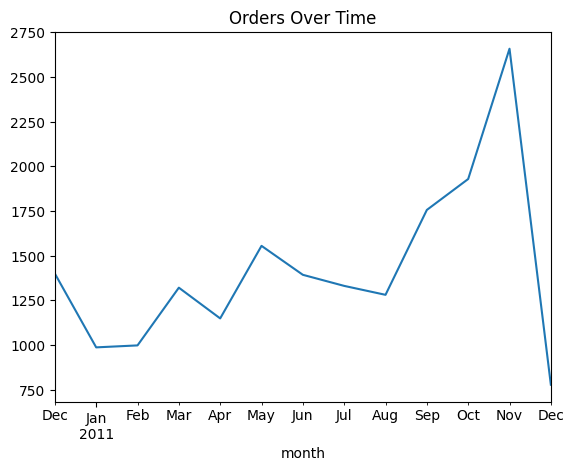

In [15]:
orders_over_time = customer_df[~customer_df['is_cancelled']].groupby('month')['Invoice'].nunique()
orders_over_time.plot(kind='line', title='Orders Over Time')

**Orders ramp up toward November.** Order volume climbs steadily through the back half of the year — 1,838 in September, 2,040 in October, 2,770 in November (the year's peak) — consistent with demand building ahead of the holiday season. This is a real trend with a direct operational implication: staffing and inventory should scale up through Q4, peaking around November.

The apparent drop to 819 orders in December 2011 (the last point on the chart above) is **not a real decline** — it's a partial-month artifact. The dataset only covers December 1–9, so that final point undercounts by roughly three weeks of data and should not be read as a post-November falloff.

## Repeat purchase rate per country

In [16]:
customer_country = customer_df.groupby('Customer ID')['Country'].first()

repeat_by_country = (
    orders_per_customer
    .merge(customer_country, on='Customer ID')
    .groupby('Country')['is_repeat_customer']
    .agg(Total_Customers='count', Repeat_Rate_pct='mean')
)
repeat_by_country['Repeat_Rate_pct'] = (repeat_by_country['Repeat_Rate_pct'] * 100).round(1)

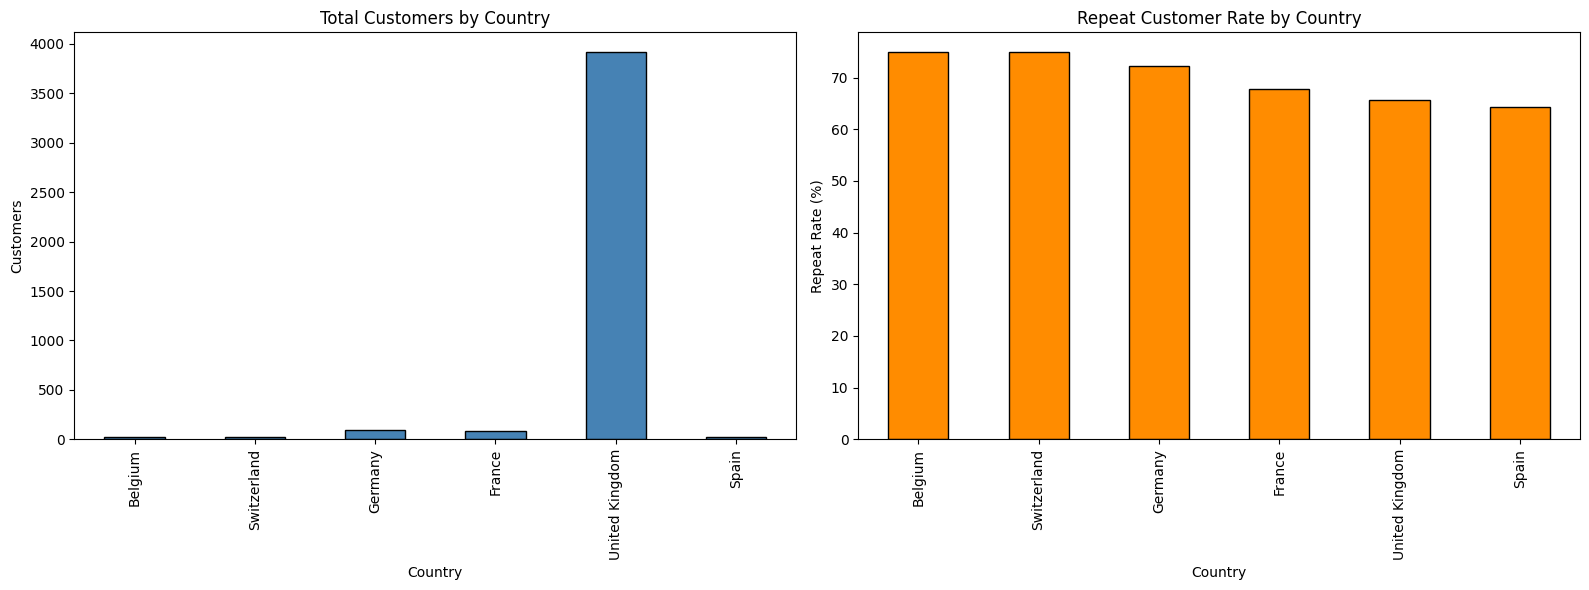

In [17]:
reliable = repeat_by_country[repeat_by_country['Total_Customers'] >= 20].sort_values('Repeat_Rate_pct', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

reliable['Total_Customers'].plot(kind='bar', ax=ax1, edgecolor='black', title='Total Customers by Country', color='steelblue')
ax1.set_xlabel('Country')
ax1.set_ylabel('Customers')

reliable['Repeat_Rate_pct'].plot(kind='bar', ax=ax2, edgecolor='black', title='Repeat Customer Rate by Country', color='darkorange')
ax2.set_xlabel('Country')
ax2.set_ylabel('Repeat Rate (%)')

plt.tight_layout()
plt.show()

In [18]:
avg_order_by_country

Country
Singapore               3039.898571
Netherlands             3004.698316
Australia               2429.014211
Japan                   1969.282632
Lebanon                 1693.880000
Israel                  1443.168000
Brazil                  1143.600000
Switzerland             1106.744118
Sweden                  1065.773056
Denmark                 1053.074444
EIRE                    1020.240231
Norway                  1004.595556
RSA                     1002.310000
Greece                   952.104000
Cyprus                   843.928125
Channel Islands          786.174615
USA                      716.078000
Spain                    683.984000
United Arab Emirates     634.093333
Iceland                  615.714286
Canada                   611.063333
Austria                  599.922353
Portugal                 585.541053
Finland                  549.904390
Malta                    545.118000
France                   537.152468
Germany                  500.390372
Italy               

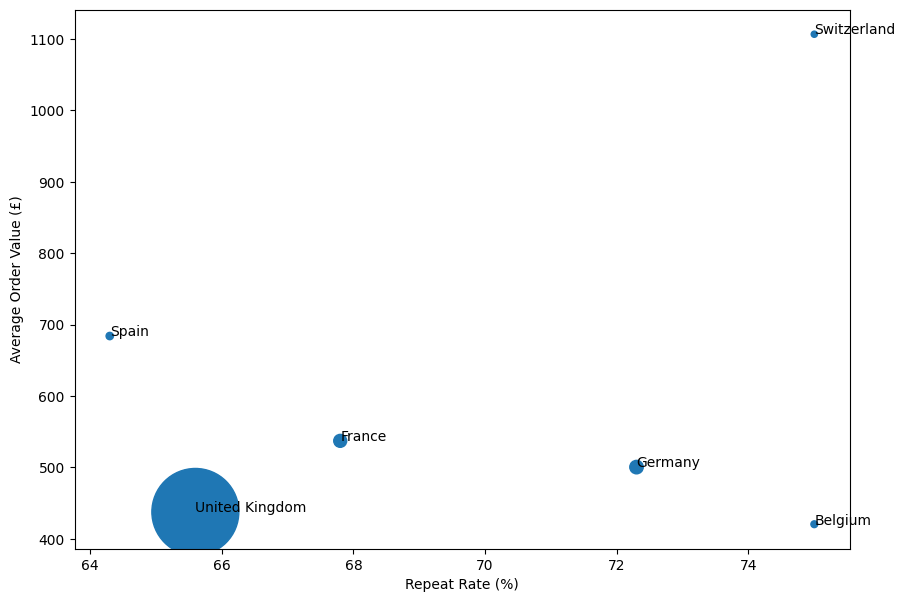

In [19]:
repeat_by_country = repeat_by_country.reset_index()
avg_order_by_country = avg_order_by_country.reset_index()

compare = repeat_by_country.merge(avg_order_by_country, on='Country')
compare = compare[compare['Total_Customers'] >= 20]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(compare['Repeat_Rate_pct'], compare['line_revenue'], s=compare['Total_Customers'])

for _, row in compare.iterrows():
    ax.annotate(row['Country'], (row['Repeat_Rate_pct'], row['line_revenue']))

ax.set_xlabel('Repeat Rate (%)')
ax.set_ylabel('Average Order Value (£)')
plt.show()

## Takeaways

Order counts are heavily skewed: most customers place just 1 order, with the distribution dropping off sharply and a long tail of high-frequency buyers (up to 209 orders from a single customer) — the capped-at-10+ histogram undersells how concentrated this really is.

Repeat customers are worth far more per person than one-time buyers: **£2,908 average revenue for repeat customers vs. £411 for one-time buyers** — roughly a 7x gap. This isn't just "more orders → more revenue" by definition; it confirms repeat buyers are the more valuable segment to retain, consistent with `05`'s RFM finding that a concentrated top tier drives most revenue.

Revenue is also concentrated at the customer level, not just the repeat/one-time split: the **top 10 customers alone account for ~17% of total non-cancelled revenue**.

The business is overwhelmingly UK-based — **88.8% of transaction rows are from the United Kingdom**, with Germany and France a distant second and third. Country-level spend/order/AOV comparisons should be read with that imbalance in mind; smaller countries' bars are based on far fewer data points and are less statistically stable.

Repeat purchase rate by country doesn't support a "friction is suppressing international demand" story. After excluding countries with fewer than 20 customers as unreliable, only 6 of 37 countries qualify: United Kingdom, Germany, France, Spain, Belgium, Switzerland. If friction (shipping cost, delivery time, no local payment option) were suppressing international demand, we'd expect high AOV paired with a *lower* repeat rate than the UK's 65.6% — customers spending well once, then not returning. That's not what the data shows: every reliable international country has a repeat rate at or above the UK's, not below it. Switzerland has both the highest AOV (£1,106.74 — more than double the UK's £437.57) and the highest repeat rate (75.0%) in the set; Germany and France also beat the UK on both AOV and repeat rate simultaneously.

International customers aren't struggling to come back — if anything they're more loyal and spend more per order than UK customers. International customers are **~9.7% of the customer base but generate ~18.0% of revenue** — nearly double their proportional share. The UK/international revenue split isn't explained by a broken repeat experience abroad; it's explained by there being far fewer international customers reaching the store in the first place (94 in Germany vs. 3,920 in the UK — a scale gap, not a satisfaction gap).

The business action that follows is different from what a friction hypothesis would suggest: this doesn't point to "fix shipping/checkout friction," it points to "the demand that exists internationally converts well — the constraint is customer acquisition/reach, not retention." That's a marketing/reach lever, not an operations one.